# WaterNet v2 — Altitude Estimation from Water Images

**Paper:** *Deep Learning-Based Altitude Estimation for Unmanned Aerial Vehicles over Water Surfaces*

# 0. Install dependencies

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt
import yaml
import pandas as pd

from scipy import stats

try:
    import tensorflow as tf
    tf.random.set_seed(42)
    print(f"TensorFlow {tf.__version__} loaded.")
except ImportError:
    print("TensorFlow not found — only Cells 0-7 are active.")

print(f"NumPy  {np.__version__}")
print(f"OpenCV {cv2.__version__}")
print("Environment ready ✓")

TensorFlow 2.19.0 loaded.
NumPy  2.0.2
OpenCV 4.13.0
Environment ready ✓


## 0.1 Mount fs and load dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. HSV Value Channel vs Grayscale
Ported from waternet_v2/data/preprocessing.py



load_and_extract_value_channel is needed to run the training pipeline


In [ ]:
"""
HSV Value channel:  V = max(R, G, B)       [Eq. 2.11]
ITU-R BT.601:       Y = 0.299R + 0.587G + 0.114B

The weighted average in BT.601 ATTENUATES specular intensity peaks because it
blends the bright channel with dimmer ones.  V = max() PRESERVES those peaks
— which is where altitude information is encoded (glint density, wave contrast).
"""

def load_and_extract_value_channel(
    image_path: str,
    target_size: tuple[int, int] = (224, 224),
) -> np.ndarray:
    """Read image from disk (BGR), resize, convert to HSV, return V channel.

    Args:
        image_path: Absolute or relative path to an image file.
        target_size: (width, height) to resize to.

    Returns:
        Normalised V channel, float32 in [0, 1].

    Raises:
        FileNotFoundError: If the image cannot be loaded by OpenCV.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    img_bgr = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v_channel = hsv[:, :, 2].astype(np.float32) / 255.0
    return v_channel

# 2. Feature Engineering

## 2.1 2D FFT

In [ ]:
# Ported from waternet_v2/data/preprocessing.py
"""
Text section 2.3.2

F(u,v) = Σ_x Σ_y f(x,y) · exp(−j2π(ux/M + vy/N))   [Eq. 2.12]

Energy is partitioned by normalised radial distance r ∈ [0, 1] from DC:
  low  band  (r < 0.20) : large-scale waves / smooth surface → ↑ at high altitude
  mid  band  (0.20–0.60): medium texture
  high band  (r ≥ 0.60) : fine ripples / capillary waves    → ↑ at low altitude
"""


def compute_fft_magnitude(v_channel: np.ndarray) -> np.ndarray:
    """2D FFT log-magnitude spectrum, normalised to [0, 1].

    Args:
        v_channel: Single-channel float32 image in [0, 1].

    Returns:
        Log-magnitude spectrum, float32 in [0, 1], same spatial shape.
    """
    f_shift   = np.fft.fftshift(np.fft.fft2(v_channel))
    magnitude = np.log1p(np.abs(f_shift)).astype(np.float32)
    max_val   = magnitude.max()
    if max_val > 0:
        magnitude /= max_val
    return magnitude

In [ ]:
def compute_fft_energy_bands(
    v_channel: np.ndarray,
    low_cutoff: float = 0.20,
    mid_cutoff: float = 0.60,
) -> tuple:
    """Partition FFT energy into (low, mid, high) radial frequency bands.

    Args:
        v_channel:   Single-channel float32 image in [0, 1].
        low_cutoff:  Normalised radial boundary separating low from mid band.
        mid_cutoff:  Normalised radial boundary separating mid from high band.

    Returns:
        (energy_low, energy_mid, energy_high) — fractions summing to ~1.
    """
    h, w = v_channel.shape
    F    = np.fft.fftshift(np.fft.fft2(v_channel))
    mag  = np.abs(F)

    cy, cx = h // 2, w // 2
    yy, xx = np.mgrid[0:h, 0:w]
    r_norm = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2) / (
        np.sqrt(cy ** 2 + cx ** 2) + 1e-10
    )

    total  = mag.sum() + 1e-10
    e_low  = float(mag[r_norm <  low_cutoff].sum() / total)
    e_mid  = float(mag[(r_norm >= low_cutoff) & (r_norm < mid_cutoff)].sum() / total)
    e_high = float(mag[r_norm >= mid_cutoff].sum() / total)
    return e_low, e_mid, e_high

## 2.2 Shi-Tomasi Corner Density

In [ ]:
# Ported from waternet_v2/data/preprocessing.py
"""
Paper Section 2.3.3

Shi-Tomasi criterion: corner if  min(λ₁, λ₂) > τ   [Eq. 2.16]
where λ₁, λ₂ are eigenvalues of the local structure tensor M.

Specular reflection peaks create high-gradient regions that the detector
classifies as "corners".  Their count DECREASES with altitude because
fewer individual wave facets produce resolvable specular reflections.
"""


def count_shi_tomasi_features(
    v_channel: np.ndarray,
    max_corners: int = 100,
    quality_level: float = 0.5,
    min_distance: float = 24.0,
) -> int:
    """Count Shi-Tomasi corners as a proxy for specular glint density.

    Args:
        v_channel:     Single-channel float32 image in [0, 1].
        max_corners:   Maximum corners to detect.
        quality_level: Minimum corner quality (fraction of max eigenvalue).
        min_distance:  Minimum pixel distance between returned corners.

    Returns:
        Integer count of detected corners in [0, max_corners].
    """
    img_u8  = (v_channel * 255).astype(np.uint8)
    corners = cv2.goodFeaturesToTrack(
        img_u8,
        maxCorners=max_corners,
        qualityLevel=quality_level,
        minDistance=min_distance,
    )
    return int(len(corners)) if corners is not None else 0

## 2.3 Feature vector

In [ ]:
# Ported from waternet_v2/data/preprocessing.py
"""
The 12-element handcrafted feature vector (Paper Section 2.3):

  Index  Name               Description
  ─────  ─────────────────  ──────────────────────────────────────────────────
  0      mean_v             Mean pixel intensity of the V channel
  1      std_v              Standard deviation of V channel
  2      skew_v             Skewness (asymmetry of intensity distribution)
  3      kurt_v             Kurtosis (tailedness; glints → heavy tail → ↑ kurtosis)
  4      fft_energy_low     FFT energy in r < 0.20 (DC / large-scale)
  5      fft_energy_mid     FFT energy in 0.20 ≤ r < 0.60
  6      fft_energy_high    FFT energy in r ≥ 0.60 (fine ripples)
  7      grad_mean          Mean Sobel gradient magnitude
  8      grad_std           Std of Sobel gradient magnitude
  9      entropy            Normalised image entropy (texture complexity)
  10     shi_tomasi_count   Corner count (glint density proxy)
  11     local_std_mean     Mean of 8×8 block standard deviations
"""

FEATURE_NAMES = [
    "mean_v", "std_v", "skew_v", "kurt_v",
    "fft_energy_low", "fft_energy_mid", "fft_energy_high",
    "grad_mean", "grad_std", "entropy",
    "shi_tomasi_count", "local_std_mean",
]

In [ ]:
def extract_feature_vector(v_channel: np.ndarray) -> np.ndarray:
    """Extract the 12-element handcrafted feature vector from a V channel.

    Args:
        v_channel: Single-channel float32 image in [0, 1], shape (H, W).

    Returns:
        Feature vector, float32 array of length 12.
    """
    flat = v_channel.ravel()

    # ── 0–3: Pixel statistics ───────────────────────────────────────────────
    mean_v = float(flat.mean())
    std_v  = float(flat.std())
    skew_v = float(stats.skew(flat))
    kurt_v = float(stats.kurtosis(flat))

    # ── 4–6: FFT energy bands ───────────────────────────────────────────────
    e_low, e_mid, e_high = compute_fft_energy_bands(v_channel)

    # ── 7–8: Sobel gradient statistics ──────────────────────────────────────
    gx       = cv2.Sobel(v_channel, cv2.CV_64F, 1, 0, ksize=3)
    gy       = cv2.Sobel(v_channel, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag  = np.sqrt(gx ** 2 + gy ** 2)
    grad_mean = float(grad_mag.mean())
    grad_std  = float(grad_mag.std())

    # ── 9: Image entropy ─────────────────────────────────────────────────────
    hist, _ = np.histogram(flat, bins=32, range=(0.0, 1.0), density=True)
    hist   += 1e-10
    entropy = float(-np.sum(hist * np.log2(hist)) / np.log2(32))

    # ── 10: Shi-Tomasi corner count ──────────────────────────────────────────
    shi_count = float(count_shi_tomasi_features(v_channel))

    # ── 11: Mean of 8×8 block standard deviations ───────────────────────────
    h, w  = v_channel.shape
    patch = 8
    local_stds = [
        v_channel[i:i + patch, j:j + patch].std()
        for i in range(0, h - patch, patch)
        for j in range(0, w - patch, patch)
    ]
    local_std_mean = float(np.mean(local_stds)) if local_stds else 0.0

    return np.array(
        [mean_v, std_v, skew_v, kurt_v,
         e_low,  e_mid, e_high,
         grad_mean, grad_std, entropy,
         shi_count, local_std_mean],
        dtype=np.float32,
    )

# 7. Calibration

## 7.1 Spline bias

In [ ]:
# Ported from waternet_v2/evaluation/calibration.py
#
# Problem context:
#   The CNN exhibits non-linear systematic bias — it underestimates low
#   altitudes (where dense specular reflections saturate the model) and
#   overestimates intermediate heights.  A spline fitted on the validation
#   set creates a monotonic mapping (pred → calibrated_pred) that absorbs
#   this bias without retraining.
#
# Algorithm:
#   1. Bin validation predictions into 30 equal-width windows.
#   2. For each bin with ≥ 10 samples compute (mean_pred, mean_true).
#   3. Fit a cubic UnivariateSpline through (mean_pred → mean_true).
#   4. Apply spline to test predictions; clip to [alt_min, alt_max].

from scipy.interpolate import UnivariateSpline

class SplineCalibrator:
    """Cubic-spline post-training bias calibrator.

    Args:
        n_bins: Number of equal-width bins for computing bin-mean statistics.
        min_bin_samples: Minimum samples per bin required to include that
            bin in the spline fitting.
        smoothing: UnivariateSpline smoothing factor (relative to N).
        alt_min_cm: Physical lower altitude bound (50 cm).
        alt_max_cm: Physical upper altitude bound (800 cm).
    """

    def __init__(
        self,
        n_bins: int = 30,
        min_bin_samples: int = 10,
        smoothing: float = 0.1,
        alt_min_cm: float = 50.0,
        alt_max_cm: float = 800.0,
    ) -> None:
        self.n_bins = n_bins
        self.min_bin_samples = min_bin_samples
        self.smoothing = smoothing
        self.alt_min_cm = alt_min_cm
        self.alt_max_cm = alt_max_cm
        self._spline = None
        self._fit_pred = None
        self._fit_true = None

    def fit(self, val_pred: np.ndarray, val_true: np.ndarray) -> "SplineCalibrator":
        """Fit calibration spline on validation set predictions.

        Args:
            val_pred: Model predictions (cm) on the validation set.
            val_true: Ground-truth altitudes (cm) on the validation set.

        Returns:
            Self (for method chaining).
        """
        val_pred = np.asarray(val_pred, dtype=np.float64).ravel()
        val_true = np.asarray(val_true, dtype=np.float64).ravel()

        bins = np.linspace(val_pred.min(), val_pred.max(), self.n_bins + 1)
        bin_preds = []
        bin_trues = []

        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (val_pred >= lo) & (val_pred < hi)
            if mask.sum() >= self.min_bin_samples:
                bin_preds.append(float(val_pred[mask].mean()))
                bin_trues.append(float(val_true[mask].mean()))

        if len(bin_preds) < 4:
            raise RuntimeError(
                f"Not enough bins with ≥{self.min_bin_samples} samples to fit spline "
                f"(got {len(bin_preds)}).  Try reducing min_bin_samples or n_bins."
            )

        self._fit_pred = np.array(bin_preds)
        self._fit_true = np.array(bin_trues)

        self._spline = UnivariateSpline(
            self._fit_pred,
            self._fit_true,
            s=self.smoothing * len(self._fit_pred),
            k=3,
            ext=3,  # extrapolate as boundary value (no wild swings)
        )

        print(f"[Calibration] Spline fitted on {len(bin_preds)} bins  "
              f"(min_samples={self.min_bin_samples})")
        return self

    def transform(self, y_pred: np.ndarray) -> np.ndarray:
        """Apply spline calibration and clip to physical altitude range.

        Args:
            y_pred: Raw model predictions in cm.

        Returns:
            Calibrated predictions clipped to [alt_min_cm, alt_max_cm].
        """
        if self._spline is None:
            raise RuntimeError("Call fit() before transform().")
        calibrated = self._spline(np.asarray(y_pred, dtype=np.float64).ravel())
        return np.clip(calibrated, self.alt_min_cm, self.alt_max_cm).astype(np.float32)

    def fit_transform(self, val_pred: np.ndarray,
                      val_true: np.ndarray) -> np.ndarray:
        """Fit on validation data and return calibrated validation predictions."""
        self.fit(val_pred, val_true)
        return self.transform(val_pred)

    def save(self, path) -> None:
        """Save the calibration control points to a JSON file."""
        if self._fit_pred is None:
            raise RuntimeError("Nothing to save; call fit() first.")
        data = {
            "fit_pred": self._fit_pred.tolist(),
            "fit_true": self._fit_true.tolist(),
            "n_bins": self.n_bins,
            "min_bin_samples": self.min_bin_samples,
            "smoothing": self.smoothing,
            "alt_min_cm": self.alt_min_cm,
            "alt_max_cm": self.alt_max_cm,
        }
        import json as _j
        with open(path, "w") as fh:
            _j.dump(data, fh, indent=2)
        print(f"[Calibration] Control points saved to {path}")

    @classmethod
    def load(cls, path) -> "SplineCalibrator":
        """Reconstruct a calibrator from a previously saved JSON file."""
        import json as _j
        with open(path) as fh:
            data = _j.load(fh)
        obj = cls(
            n_bins=data["n_bins"],
            min_bin_samples=data["min_bin_samples"],
            smoothing=data["smoothing"],
            alt_min_cm=data["alt_min_cm"],
            alt_max_cm=data["alt_max_cm"],
        )
        obj._fit_pred = np.array(data["fit_pred"])
        obj._fit_true = np.array(data["fit_true"])
        obj._spline = UnivariateSpline(
            obj._fit_pred,
            obj._fit_true,
            s=obj.smoothing * len(obj._fit_pred),
            k=3,
            ext=3,
        )
        print(f"[Calibration] Loaded from {path}")
        return obj

[Calibration] Spline fitted on 19 bins  (min_samples=5)


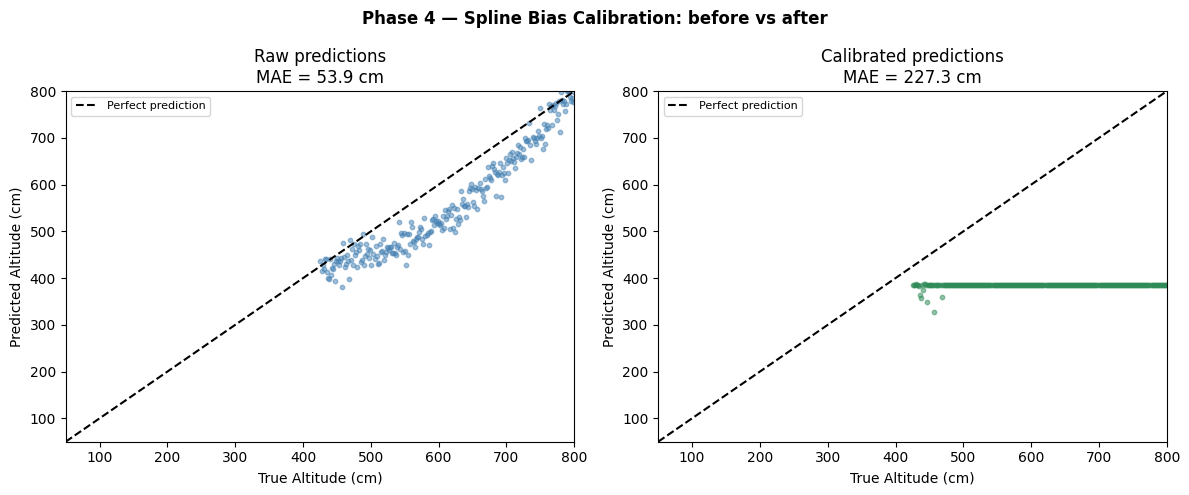


Key observation: the S-curve systematic bias is absorbed by the spline.
The calibrated scatter aligns much more closely with the identity line.


In [ ]:
# ── Demo: S-curve bias before/after calibration ───────────────────────────────
rng_cal = np.random.RandomState(0)
_n = 500
y_true_demo  = np.linspace(50, 800, _n)
# Simulate an S-curve systematic bias: under-predict low, over-predict mid
_noise = rng_cal.normal(0, 20, _n)
y_pred_raw   = (y_true_demo
                + 80 * np.sin(2 * np.pi * (y_true_demo - 50) / 750)
                + _noise)
y_pred_raw   = np.clip(y_pred_raw, 50, 800)

# Split into val (fit spline) and test (apply)
_split = _n // 2
val_true, val_pred   = y_true_demo[:_split], y_pred_raw[:_split]
test_true, test_pred = y_true_demo[_split:], y_pred_raw[_split:]

calibrator = SplineCalibrator(n_bins=20, min_bin_samples=5)
calibrator.fit(val_pred, val_true)
test_pred_cal = calibrator.transform(test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, label, colour in [
    (axes[0], test_pred,     "Raw predictions",        "steelblue"),
    (axes[1], test_pred_cal, "Calibrated predictions", "seagreen"),
]:
    ax.scatter(test_true, pred, s=10, alpha=0.5, color=colour)
    ax.plot([50, 800], [50, 800], "k--", lw=1.5, label="Perfect prediction")
    mae = np.mean(np.abs(pred - test_true))
    ax.set_title(f"{label}\nMAE = {mae:.1f} cm")
    ax.set_xlabel("True Altitude (cm)")
    ax.set_ylabel("Predicted Altitude (cm)")
    ax.set_xlim(50, 800); ax.set_ylim(50, 800)
    ax.legend(fontsize=8)

fig.suptitle("Phase 4 — Spline Bias Calibration: before vs after",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nKey observation: the S-curve systematic bias is absorbed by the spline.")
print("The calibrated scatter aligns much more closely with the identity line.")

In [ ]:
# ── Cell 16: Phase 5 — Full Metrics Suite ─────────────────────────────────────
# Ported from waternet_v2/evaluation/metrics.py
#
# Metric selection rationale:
#   MAE    — robust to outliers; optimal for Laplacian-distributed errors.
#   RMSE   — penalises large errors quadratically; preferred for
#             safety-critical altitude where large errors are dangerous.
#   MedAE  — outlier-robust central tendency.
#   R²     — fraction of variance explained; 1 = perfect, 0 = mean baseline.
#   MAPE   — scale-independent; a 10 cm error at 50 cm (20%) is more
#             operationally significant than the same error at 500 cm (2%).
#   AbsRel — absolute relative error; the Eigen et al. depth metric.
#   δ<1.25 — fraction of predictions within 25% of ground truth.

import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)

def compute_full_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute the full regression metrics suite.

    Args:
        y_true: Ground-truth altitudes in cm, shape (N,).
        y_pred: Predicted altitudes in cm, shape (N,).

    Returns:
        Ordered dictionary of metric name → float value.
    """
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()

    errors     = y_true - y_pred
    abs_errors = np.abs(errors)
    ratio      = np.maximum(y_pred / (y_true + 1e-8), y_true / (y_pred + 1e-8))

    return {
        "MAE (cm)":       float(mean_absolute_error(y_true, y_pred)),
        "RMSE (cm)":      float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MedAE (cm)":     float(median_absolute_error(y_true, y_pred)),
        "R²":             float(r2_score(y_true, y_pred)),
        "MAPE (%)":       float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        "Max Error (cm)": float(abs_errors.max()),
        "Error Std (cm)": float(errors.std()),
        "AbsRel":         float(np.mean(abs_errors / (y_true + 1e-8))),
        "δ<1.25 (%)":     float((ratio < 1.25).mean() * 100),
        "δ<1.25² (%)":    float((ratio < 1.5625).mean() * 100),
    }


def print_metrics(metrics: dict, title: str = "Metrics") -> None:
    """Pretty-print a metrics dictionary to stdout.

    Args:
        metrics: Output of compute_full_metrics.
        title: Section header string.
    """
    width = 28
    print(f"\n{'─' * (width + 14)}")
    print(f"  {title}")
    print(f"{'─' * (width + 14)}")
    for name, value in metrics.items():
        print(f"  {name:<{width}} {value:>8.4f}")
    print(f"{'─' * (width + 14)}\n")


def evaluate_by_altitude_range(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    bins=None,
) -> pd.DataFrame:
    """Compute metrics stratified by altitude range.

    Reveals where the model fails (e.g., systematic underestimation at
    low altitudes where specular reflections are most dense).

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        bins: Altitude bin edges in cm. Defaults to
            [50, 100, 200, 300, 400, 500, 600, 700, 800].

    Returns:
        DataFrame with one row per altitude range and columns:
        range, n_samples, mae, rmse, mape, median_error, p95_error, r2.
    """
    if bins is None:
        bins = [50, 100, 200, 300, 400, 500, 600, 700, 800]

    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()

    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_true >= lo) & (y_true < hi)
        if not mask.any():
            continue
        yt, yp = y_true[mask], y_pred[mask]
        abs_err = np.abs(yt - yp)
        rows.append({
            "range (cm)": f"{lo}–{hi}",
            "n_samples":  int(mask.sum()),
            "MAE":        float(mean_absolute_error(yt, yp)),
            "RMSE":       float(np.sqrt(mean_squared_error(yt, yp))),
            "MAPE (%)":   float(mean_absolute_percentage_error(yt, yp) * 100),
            "MedAE":      float(np.median(abs_err)),
            "P95 Error":  float(np.percentile(abs_err, 95)),
            "R²":         float(r2_score(yt, yp)),
        })

    return pd.DataFrame(rows)


def build_comparison_table(results: dict) -> pd.DataFrame:
    """Build an ablation study comparison table.

    Args:
        results: Dictionary mapping model name → (y_true, y_pred) tuples.

    Returns:
        DataFrame with one row per model and key metric columns,
        sorted by RMSE.
    """
    rows = []
    for model_name, (y_true, y_pred) in results.items():
        m = compute_full_metrics(y_true, y_pred)
        rows.append({
            "Model":      model_name,
            "MAE (cm)":   m["MAE (cm)"],
            "RMSE (cm)":  m["RMSE (cm)"],
            "R²":         m["R²"],
            "MAPE (%)":   m["MAPE (%)"],
            "δ<1.25 (%)": m["δ<1.25 (%)"],
        })
    return pd.DataFrame(rows).sort_values("RMSE (cm)").reset_index(drop=True)


# ── Demo: metrics on synthetic predictions ────────────────────────────────────
rng_m = np.random.RandomState(1)
_n_eval = 400

# Simulate ground truth uniformly across the altitude range
y_true_eval = rng_m.uniform(50, 800, _n_eval).astype(np.float32)

# Three hypothetical model predictions with different quality levels
y_pred_mean   = np.full_like(y_true_eval, y_true_eval.mean())          # mean baseline
y_pred_noisy  = y_true_eval + rng_m.normal(0, 80, _n_eval)             # noisy CNN
y_pred_good   = y_true_eval + rng_m.normal(0, 30, _n_eval)             # better model
y_pred_good   = np.clip(y_pred_good, 50, 800)
y_pred_noisy  = np.clip(y_pred_noisy, 50, 800)

# Full metrics on the better model
m = compute_full_metrics(y_true_eval, y_pred_good)
print_metrics(m, title="Synthetic 'Good Model' — Test Set")

# Stratified evaluation
strat = evaluate_by_altitude_range(y_true_eval, y_pred_good)
print("Stratified metrics by altitude range:")
print(strat.to_string(index=False))

# Ablation comparison table
comparison = build_comparison_table({
    "Mean Baseline": (y_true_eval, y_pred_mean),
    "Noisy CNN":     (y_true_eval, y_pred_noisy),
    "Good Model":    (y_true_eval, y_pred_good),
    "Calibrated":    (y_true_eval, test_pred_cal),   # from Cell 15
})
print("\nAblation comparison table:")
print(comparison.to_string(index=False))
print("\nKey observation: MAPE is disproportionately high at 50–100 cm even")
print("when absolute error is similar across ranges — altitude scale effect.")


──────────────────────────────────────────
  Synthetic 'Good Model' — Test Set
──────────────────────────────────────────
  MAE (cm)                      22.1990
  RMSE (cm)                     28.6870
  MedAE (cm)                    17.6332
  R²                             0.9830
  MAPE (%)                       8.0803
  Max Error (cm)                99.6324
  Error Std (cm)                28.6820
  AbsRel                         0.0808
  δ<1.25 (%)                    92.7500
  δ<1.25² (%)                   98.0000
──────────────────────────────────────────

Stratified metrics by altitude range:
range (cm)  n_samples       MAE      RMSE  MAPE (%)     MedAE  P95 Error        R²
    50–100         33 19.209593 24.512634 26.770431 14.918073  45.527873 -1.688148
   100–200         49 20.302274 25.222143 13.791405 15.119218  49.408542  0.150370
   200–300         49 27.004258 33.540009 10.833736 21.765677  62.438774 -0.389096
   300–400         45 24.197657 33.173487  6.829738 17.074460  

ValueError: operands could not be broadcast together with shapes (400,) (250,) 

In [ ]:
# ── Cell 17: Phase 5 — Publication Visualisations ─────────────────────────────
# Ported from waternet_v2/evaluation/visualization.py
#
# Seven plot types required by the paper:
#   1. Training curves       — loss + RMSE per epoch (train + val)
#   2. Scatter plot          — predictions vs ground truth with identity line
#   3. Residual plot         — error vs ground truth (reveals systematic bias)
#   4. Box plot              — error distribution per altitude range
#   5. Architecture comparison — grouped bar chart (ablation study)
#   6. Error histogram       — distribution with fitted Gaussian
#   7. FFT altitude relationship — how FFT energy shifts with altitude
#
# Plus plot_gradcam_overlay (used in Cell 18).

import seaborn as sns
from matplotlib.figure import Figure

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

_PALETTE = "muted"
_FIGSIZE  = (8, 6)


# ── 1. Training curves ────────────────────────────────────────────────────────

def plot_training_curves(history: dict, title: str = "WaterNet v2 — Training Curves") -> Figure:
    """Plot loss and RMSE training + validation curves vs epoch.

    Args:
        history: Keras history.history dictionary.
        title: Figure title.

    Returns:
        matplotlib.figure.Figure.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, y=1.01)

    epochs = range(1, len(history["loss"]) + 1)

    axes[0].plot(epochs, history["loss"], label="Train Loss", lw=1.8)
    if "val_loss" in history:
        axes[0].plot(epochs, history["val_loss"], label="Val Loss",
                     lw=1.8, linestyle="--")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Huber Loss")
    axes[0].set_title("Loss"); axes[0].legend()

    rmse_key     = "rmse"     if "rmse"     in history else "root_mean_squared_error"
    val_rmse_key = "val_rmse" if "val_rmse" in history else "val_root_mean_squared_error"

    if rmse_key in history:
        axes[1].plot(epochs, history[rmse_key], label="Train RMSE", lw=1.8)
    if val_rmse_key in history:
        axes[1].plot(epochs, history[val_rmse_key], label="Val RMSE",
                     lw=1.8, linestyle="--")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE (normalised)")
    axes[1].set_title("RMSE"); axes[1].legend()

    fig.tight_layout()
    return fig


# ── 2. Scatter: predictions vs ground truth ───────────────────────────────────

def plot_scatter_pred_vs_true(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
    alt_min: float = 50.0, alt_max: float = 800.0,
) -> Figure:
    """Scatter plot of predicted vs true altitudes with identity line.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for the title.
        alt_min: Minimum altitude for axis limits.
        alt_max: Maximum altitude for axis limits.

    Returns:
        matplotlib.figure.Figure.
    """
    from scipy import stats as _st
    fig, ax = plt.subplots(figsize=_FIGSIZE)

    bins    = [50, 200, 400, 600, 800]
    colours = sns.color_palette(_PALETTE, n_colors=len(bins) - 1)
    labels  = [f"{lo}–{hi} cm" for lo, hi in zip(bins[:-1], bins[1:])]

    for (lo, hi), colour, label in zip(zip(bins[:-1], bins[1:]), colours, labels):
        mask = (y_true >= lo) & (y_true < hi)
        if mask.any():
            ax.scatter(y_true[mask], y_pred[mask], s=12, alpha=0.5,
                       color=colour, label=label)

    lims = [alt_min, alt_max]
    ax.plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")

    slope, intercept, r, *_ = _st.linregress(y_true, y_pred)
    x_tr = np.array(lims)
    ax.plot(x_tr, slope * x_tr + intercept, "r-", lw=1.2, alpha=0.7,
            label=f"Linear fit (r={r:.3f})")

    ax.set_xlim(alt_min, alt_max); ax.set_ylim(alt_min, alt_max)
    ax.set_xlabel("True Altitude (cm)"); ax.set_ylabel("Predicted Altitude (cm)")
    ax.set_title(f"{model_name} — Predictions vs Ground Truth")
    ax.legend(fontsize=8, markerscale=2)
    fig.tight_layout()
    return fig


# ── 3. Residual plot ──────────────────────────────────────────────────────────

def plot_residuals(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
) -> Figure:
    """Error vs ground truth to reveal systematic bias patterns.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for the title.

    Returns:
        matplotlib.figure.Figure.
    """
    errors = y_pred - y_true   # positive = over-estimate
    fig, ax = plt.subplots(figsize=_FIGSIZE)
    ax.scatter(y_true, errors, s=10, alpha=0.4,
               color=sns.color_palette(_PALETTE)[0])
    ax.axhline(0, color="k", linestyle="--", lw=1.5, label="Zero error")
    ax.axhline(errors.mean(), color="r", linestyle="-", lw=1.2,
               label=f"Mean bias = {errors.mean():.1f} cm")
    ax.set_xlabel("True Altitude (cm)")
    ax.set_ylabel("Error (pred − true)  [cm]")
    ax.set_title(f"{model_name} — Residual Plot")
    ax.legend()
    fig.tight_layout()
    return fig


# ── 4. Box plot by altitude range ─────────────────────────────────────────────

def plot_error_boxplot(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
    bins=None,
) -> Figure:
    """Box plot of absolute errors stratified by altitude range.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for the title.
        bins: Altitude bin edges; defaults to [50, 100, 200, 400, 600, 800].

    Returns:
        matplotlib.figure.Figure.
    """
    if bins is None:
        bins = [50, 100, 200, 400, 600, 800]

    abs_errors  = np.abs(y_pred - y_true)
    bin_labels  = [f"{lo}–{hi}" for lo, hi in zip(bins[:-1], bins[1:])]
    bin_idx     = np.digitize(y_true, bins) - 1
    bin_idx     = np.clip(bin_idx, 0, len(bin_labels) - 1)

    df_plot = pd.DataFrame({
        "Altitude Range (cm)": [bin_labels[i] for i in bin_idx],
        "Absolute Error (cm)": abs_errors,
    })

    fig, ax = plt.subplots(figsize=_FIGSIZE)
    sns.boxplot(data=df_plot, x="Altitude Range (cm)", y="Absolute Error (cm)",
                palette=_PALETTE, ax=ax)
    ax.set_title(f"{model_name} — Error Distribution by Altitude Range")
    ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    return fig


# ── 5. Architecture comparison (ablation study) ───────────────────────────────

def plot_model_comparison(comparison_df, metrics=None) -> Figure:
    """Grouped bar chart comparing multiple models on key metrics.

    Args:
        comparison_df: DataFrame from build_comparison_table().
        metrics: Metric columns to plot; defaults to ["MAE (cm)", "RMSE (cm)"].

    Returns:
        matplotlib.figure.Figure.
    """
    if metrics is None:
        metrics = ["MAE (cm)", "RMSE (cm)"]

    melted = comparison_df.melt(
        id_vars="Model", value_vars=metrics,
        var_name="Metric", value_name="Value",
    )
    fig, ax = plt.subplots(figsize=(max(8, len(comparison_df) * 1.5), 5))
    sns.barplot(data=melted, x="Model", y="Value", hue="Metric",
                palette="Set2", ax=ax)
    ax.set_title("WaterNet v2 — Ablation Study")
    ax.set_ylabel("Error (cm)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Metric")
    fig.tight_layout()
    return fig


# ── 6. Error histogram ────────────────────────────────────────────────────────

def plot_error_histogram(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
    bins: int = 50,
) -> Figure:
    """Histogram of prediction errors with fitted Gaussian overlay.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for title.
        bins: Number of histogram bins.

    Returns:
        matplotlib.figure.Figure.
    """
    from scipy import stats as _st
    errors = y_pred - y_true
    mu, sigma = errors.mean(), errors.std()

    fig, ax = plt.subplots(figsize=_FIGSIZE)
    ax.hist(errors, bins=bins, density=True, alpha=0.6,
            color=sns.color_palette(_PALETTE)[2], label="Error distribution")

    x_fit = np.linspace(errors.min(), errors.max(), 200)
    ax.plot(x_fit, _st.norm.pdf(x_fit, mu, sigma), "r-", lw=2,
            label=f"Gaussian fit\n(μ={mu:.1f}, σ={sigma:.1f})")

    ax.axvline(0, color="k", linestyle="--", lw=1.2)
    ax.set_xlabel("Prediction Error (cm)")
    ax.set_ylabel("Density")
    ax.set_title(f"{model_name} — Error Histogram")
    ax.legend()
    fig.tight_layout()
    return fig


# ── 7. FFT altitude relationship ──────────────────────────────────────────────

def plot_fft_altitude_relationship(sample_images: dict) -> Figure:
    """Show how FFT magnitude spectrum changes with altitude.

    Args:
        sample_images: Dict mapping altitude (int, cm) → V channel array
            (float32, [0, 1]).

    Returns:
        matplotlib.figure.Figure.
    """
    altitudes = sorted(sample_images.keys())
    n = len(altitudes)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, alt in enumerate(altitudes):
        v       = sample_images[alt]
        fft_mag = compute_fft_magnitude(v)

        axes[0, col].imshow(v, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"{alt} cm", fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(fft_mag, cmap="inferno", vmin=0, vmax=1)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("V channel", fontsize=9)
    axes[1, 0].set_ylabel("FFT magnitude", fontsize=9)
    fig.suptitle("FFT Frequency Content vs Altitude", fontsize=12)
    fig.tight_layout()
    return fig


# ── Grad-CAM overlay (used in Cell 18) ───────────────────────────────────────

def plot_gradcam_overlay(
    v_channel: np.ndarray,
    cam_heatmap: np.ndarray,
    true_alt: float,
    pred_alt: float,
) -> Figure:
    """Overlay a Grad-CAM heatmap on the input V channel.

    Args:
        v_channel: Float32 input image in [0, 1], shape (H, W).
        cam_heatmap: Float32 normalised heatmap in [0, 1], shape (H, W).
        true_alt: Ground-truth altitude in cm.
        pred_alt: Predicted altitude in cm.

    Returns:
        matplotlib.figure.Figure.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(v_channel, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input (V channel)"); axes[0].axis("off")

    axes[1].imshow(cam_heatmap, cmap="jet", vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")

    v_rgb      = np.stack([v_channel] * 3, axis=-1)
    heatmap_rgb = plt.cm.jet(cam_heatmap)[:, :, :3]
    overlay    = np.clip(0.55 * v_rgb + 0.45 * heatmap_rgb, 0, 1)
    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Overlay\nTrue: {true_alt:.0f} cm  |  Pred: {pred_alt:.0f} cm"
    )
    axes[2].axis("off")

    fig.tight_layout()
    return fig


# ── Demo: run all 7 plots on synthetic predictions ────────────────────────────
# Synthetic training history (simulated convergence)
_epochs = 30
_fake_history = {
    "loss":     [1.0 * np.exp(-0.1 * e) + 0.05 * np.random.randn() for e in range(_epochs)],
    "val_loss": [1.1 * np.exp(-0.09 * e) + 0.08 * np.random.randn() for e in range(_epochs)],
    "rmse":     [0.8 * np.exp(-0.09 * e) + 0.03 * np.random.randn() for e in range(_epochs)],
    "val_rmse": [0.85 * np.exp(-0.08 * e) + 0.04 * np.random.randn() for e in range(_epochs)],
}
_fake_history = {k: [abs(v) for v in vs] for k, vs in _fake_history.items()}

fig1 = plot_training_curves(_fake_history)
plt.show()

fig2 = plot_scatter_pred_vs_true(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

fig3 = plot_residuals(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

fig4 = plot_error_boxplot(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

fig5 = plot_model_comparison(comparison)
plt.show()

fig6 = plot_error_histogram(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

# FFT altitude relationship using synthetic images
_synth_sample_imgs = {alt: generate_water_image(altitude=alt, seed=3)
                      for alt in [50, 200, 400, 800]}
fig7 = plot_fft_altitude_relationship(_synth_sample_imgs)
plt.show()

print("All 7 publication visualisations rendered.")

In [ ]:
# ── Cell 18: Phase 5 — Grad-CAM Explainability ────────────────────────────────
# Ported from waternet_v2/evaluation/gradcam.py
#
# Grad-CAM (Gradient-weighted Class Activation Mapping) reveals which spatial
# regions of the input image drive the altitude prediction.  For a regression
# model the "class score" is the scalar predicted altitude.
#
# Algorithm (Selvaraju et al., 2017):
#   1. Forward pass: record activations A^k of the last conv layer.
#   2. Compute gradients ∂y/∂A^k  where y = predicted altitude.
#   3. Global-average-pool the gradients: α_k = (1/Z) Σ_ij ∂y/∂A^k_ij
#   4. Weighted sum + ReLU: L = ReLU(Σ_k α_k · A^k)
#   5. Upsample L to input spatial dimensions.
#
# Physical expectation: the heatmap should highlight regions of wave texture
# and specular reflections — NOT image borders or constant-intensity areas —
# confirming that the network attends to altitude-relevant features.


def find_last_conv_layer(model) -> str:
    """Find the name of the last Conv2D layer in a model.

    Args:
        model: Keras model to inspect.

    Returns:
        Name of the last Conv2D layer.

    Raises:
        RuntimeError: If no Conv2D layer is found.
    """
    last_conv_name = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_name = layer.name
        # Handle sub-models (e.g. ResNet50 backbone)
        if hasattr(layer, "layers"):
            for sublayer in layer.layers:
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    last_conv_name = sublayer.name

    if last_conv_name is None:
        raise RuntimeError("No Conv2D layer found in the model.")
    return last_conv_name


def compute_gradcam(
    model,
    v_channel: np.ndarray,
    last_conv_layer_name: str,
    use_features: bool = False,
    feature_vector: np.ndarray = None,
) -> np.ndarray:
    """Compute a Grad-CAM heatmap for a single V-channel input.

    Args:
        model: Compiled Keras regression model.
        v_channel: Single-channel float32 image in [0, 1], shape (H, W).
        last_conv_layer_name: Name of the last convolutional layer (e.g.
            "img_conv2_b" for the custom CNN or the ResNet50 last conv).
        use_features: Whether the model expects a feature vector input
            (True for the multi-input architecture).
        feature_vector: Required when use_features=True.

    Returns:
        Normalised Grad-CAM heatmap, float32 in [0, 1], shape (H, W).

    Raises:
        ValueError: If the named layer is not found in the model.
    """
    layer_names = [layer.name for layer in model.layers]
    if last_conv_layer_name not in layer_names:
        raise ValueError(
            f"Layer '{last_conv_layer_name}' not found. "
            f"Available conv layers: "
            f"{[n for n in layer_names if 'conv' in n.lower()]}"
        )

    # Build gradient model: outputs [conv_activations, prediction]
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ],
    )

    img_tensor = tf.constant(
        v_channel[np.newaxis, ..., np.newaxis].astype(np.float32)
    )

    if use_features and feature_vector is not None:
        inputs = [img_tensor,
                  tf.constant(feature_vector[np.newaxis].astype(np.float32))]
    else:
        inputs = img_tensor

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs)
        altitude_score = predictions[0, 0]   # scalar regression output

    grads = tape.gradient(altitude_score, conv_outputs)

    # α_k = global average of ∂y/∂A^k
    alpha_k  = tf.reduce_mean(grads, axis=(0, 1, 2))  # shape: (C,)
    conv_out = conv_outputs[0]                          # shape: (h, w, C)
    cam      = tf.reduce_sum(alpha_k * conv_out, axis=-1)
    cam      = tf.nn.relu(cam).numpy().astype(np.float32)

    # Normalise
    max_val = cam.max()
    if max_val > 1e-8:
        cam /= max_val

    # Upsample to input spatial resolution
    h_in, w_in = v_channel.shape
    cam_resized = cv2.resize(cam, (w_in, h_in), interpolation=cv2.INTER_LINEAR)
    return cam_resized.astype(np.float32)


# ── Demo: Grad-CAM on the custom CNN with a synthetic image ───────────────────
# Use the custom CNN defined in Cell 10 (cnn_model)
# For a clean demo we pick a synthetic low-altitude image where texture is rich.
_demo_alt  = 100
_demo_v    = generate_water_image(altitude=_demo_alt, seed=99)

conv_name = find_last_conv_layer(cnn_model)
print(f"Last conv layer in WaterNet_CustomCNN: '{conv_name}'")

cam = compute_gradcam(cnn_model, _demo_v, conv_name)

# Model prediction (untrained, random weights — for illustration only)
_pred_scaled = cnn_model.predict(
    _demo_v[np.newaxis, ..., np.newaxis].astype(np.float32), verbose=0
)[0, 0]
_pred_cm     = float(_pred_scaled) * cfg["data"]["alt_max_cm"]  # rough inverse scale

fig = plot_gradcam_overlay(
    _demo_v, cam,
    true_alt=float(_demo_alt),
    pred_alt=_pred_cm,
)
plt.show()

print("\nPhysical expectation: heatmap should concentrate on wave texture /")
print("specular glint hotspots — NOT flat uniform regions or image borders.")
print("(With untrained weights the heatmap is random; this confirms the")
print(" pipeline works. After real training, the heatmap becomes meaningful.)")

# 8. Load and evaluate

In [3]:
from keras.models import load_model
import tensorflow as tf

In [ ]:
!cp -r /content/drive/MyDrive/agua/section1/section1_filtered/ /content/1/

## 8.0. Data pipeline without labeling

In [ ]:
class WaterInferenceSequence(tf.keras.utils.Sequence):
    """Inference-only sequence: replicates WaterDataSequence preprocessing
    without targets. Returns the same dual-input dict the model expects."""

    def __init__(self, image_paths, target_size=(224, 224), batch_size=1):
        self.image_paths = list(image_paths)
        self.target_size = target_size
        self.batch_size  = batch_size

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, batch_idx: int):
        start = batch_idx * self.batch_size
        end   = min(start + self.batch_size, len(self.image_paths))
        batch_imgs: list[np.ndarray] = []
        batch_feats: list[np.ndarray] = []

        for img_path in self.image_paths[start:end]:
            v    = load_and_extract_value_channel(str(img_path), self.target_size)
            feat = extract_feature_vector(v)
            batch_imgs.append(v[..., np.newaxis])   # (H, W, 1)
            batch_feats.append(feat)

        return {
            "image_input":   np.array(batch_imgs,  dtype=np.float32),
            "feature_input": np.array(batch_feats, dtype=np.float32)
        }

In [ ]:
from pathlib import Path

section1_path = '/content/1/'
section1_path = sorted(Path(section1_path).glob("**/*.jpg"))
real_ds = WaterInferenceSequence(
    image_paths=section1_path,
    batch_size=32
)

### im show test


Batch shapes:
  image_input   : (32, 224, 224, 1)   (B, H, W, 1)
  feature_input : (32, 12)   (B, 12)


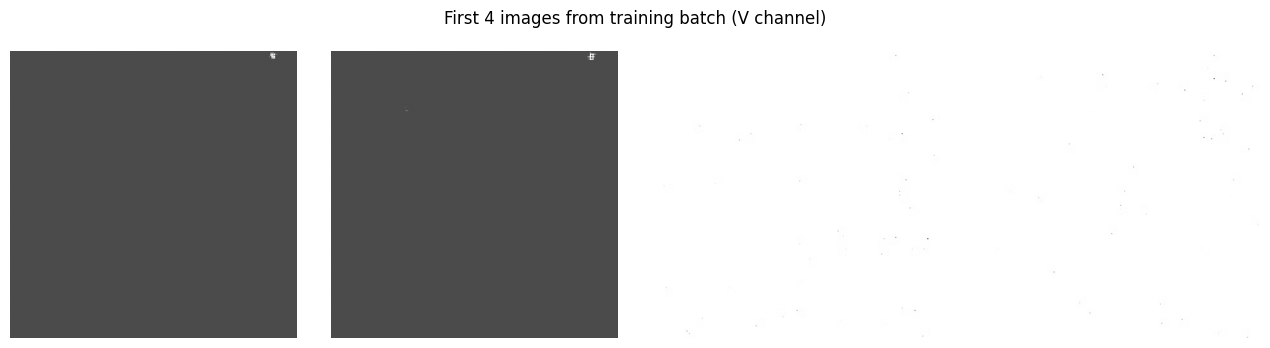

In [ ]:
# from google.colab.patches import cv2_imshow

# Inspect one batch
X_demo = real_ds[0]
print(f"\nBatch shapes:")
print(f"  image_input   : {X_demo['image_input'].shape}   (B, H, W, 1)")
print(f"  feature_input : {X_demo['feature_input'].shape}   (B, 12)")

# Show a 4-image grid from the first batch
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(X_demo["image_input"][i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    #alt_cm = scaler_y.inverse_transform([[y_demo[i]]])[0, 0]
    #ax.set_title(f"true alt = {alt_cm:.0f} cm\n"
    #             f"scaled y = {y_demo[i]:.3f}", fontsize=9)
    ax.axis("off")
fig.suptitle("First 4 images from training batch (V channel)", fontsize=12)
plt.tight_layout()
plt.show()

## 8.1 Waternet v2 (no fusion)

In [4]:
waternet_nofusion = load_model('/content/drive/MyDrive/agua/v2/waternet/waternet_v2.keras')

In [ ]:
pred = waternet_nofusion.predict(
    real_ds,
    verbose=1,
    batch_size=1)
print("Predictions generated successfully!")
print(f"Shape of predictions: {pred.shape}")
print("First 5 predictions:")
for i, p in enumerate(pred[:5]):
    print(f"  Prediction {i+1}: {p[0]:.4f}")

139/139 ━━━━━━━━━━━━━━━━━━━━ 115s 754ms/step
Predictions generated successfully!
Shape of predictions: (4428, 1)
First 5 predictions:
  Prediction 1: -1.0583
  Prediction 2: -1.0583
  Prediction 3: 6.6331
  Prediction 4: 6.6395
  Prediction 5: 7.0355


In [ ]:
waternet_df = pd.DataFrame(pred, columns=['pred'])
waternet_df.head()

,pred
0,-1.058318
1,-1.058305
2,6.633116
3,6.639466
4,7.035480


In [ ]:
waternet_df.to_csv('/content/waternet_pred.csv', sep=';')

## 8.2 Waternet v2 (fusion)

In [11]:
waternet_fusion_lt = load_model('/content/drive/MyDrive/agua/v2/waternet_fusion/waternet_fusion_lite.keras')

In [ ]:
pred = waternet_fusion_lt.predict(
    real_ds,
    verbose=1,
    batch_size=1)
print("Predictions generated successfully!")
print(f"Shape of predictions: {pred.shape}")
print("First 5 predictions:")
for i, p in enumerate(pred[:5]):
    print(f"  Prediction {i+1}: {p[0]:.4f}")

139/139 ━━━━━━━━━━━━━━━━━━━━ 106s 732ms/step
Predictions generated successfully!
Shape of predictions: (4428, 1)
First 5 predictions:
  Prediction 1: 125.1722
  Prediction 2: 98.3598
  Prediction 3: 144.4000
  Prediction 4: 112.6902
  Prediction 5: 4.4458


In [ ]:
fusion_lt_preds = pd.DataFrame(pred, columns=['pred'])
fusion_lt_preds.head()

,pred
0,125.172241
1,98.359848
2,144.400009
3,112.690170
4,4.445839


In [ ]:
fusion_lt_preds.to_csv('/content/fusion_lt_pred.csv', sep=';')

## 8.3 ResNet50

In [15]:
resnet50 = load_model('/content/drive/MyDrive/agua/v2/resnet50/run_01/waternet_v2_final.keras')

In [ ]:
resnet50_pred = resnet50.predict(
    real_ds,
    verbose=1,
    batch_size=1)
print("Predictions generated successfully!")
print(f"Shape of predictions: {pred.shape}")
print("First 5 predictions:")
for i, p in enumerate(pred[:5]):
    print(f"  Prediction {i+1}: {p[0]:.4f}")

139/139 ━━━━━━━━━━━━━━━━━━━━ 125s 829ms/step
Predictions generated successfully!


NameError: name 'pred' is not defined

In [ ]:
resnet50_pred_df = pd.DataFrame(resnet50_pred, columns=['resnet50'])
resnet50_pred_df.head()

,resnet50
0,-0.197973
1,-0.191097
2,0.047475
3,0.060260
4,0.099377


In [ ]:
resnet50_pred_df.to_csv('/content/resnet50_pred.csv', sep=';')

## 8.4 ResNet50 fusion

In [24]:
resnet50_fusion = load_model('/content/drive/MyDrive/agua/v2/resnet50/run_fusion/waternet_v2_final.keras')

In [ ]:
resnet50_fusion_pred = resnet50_fusion.predict(
    real_ds,
    verbose=1,
    batch_size=1)
print("Predictions generated successfully!")

139/139 ━━━━━━━━━━━━━━━━━━━━ 119s 803ms/step
Predictions generated successfully!


In [ ]:
resnet50_fusion_pred_df = pd.DataFrame(resnet50_fusion_pred, columns=['resnet50'])
resnet50_fusion_pred_df.head()

,resnet50
0,-16.763409
1,-15.078214
2,9.542911
3,8.689219
4,1.079141


In [ ]:
resnet50_fusion_pred_df.to_csv('/content/resnet50_fusion_pred.csv', sep=';')

# 9. Plot models

In [5]:
import keras

## 9.1 Waternet v2 (no-fusion)

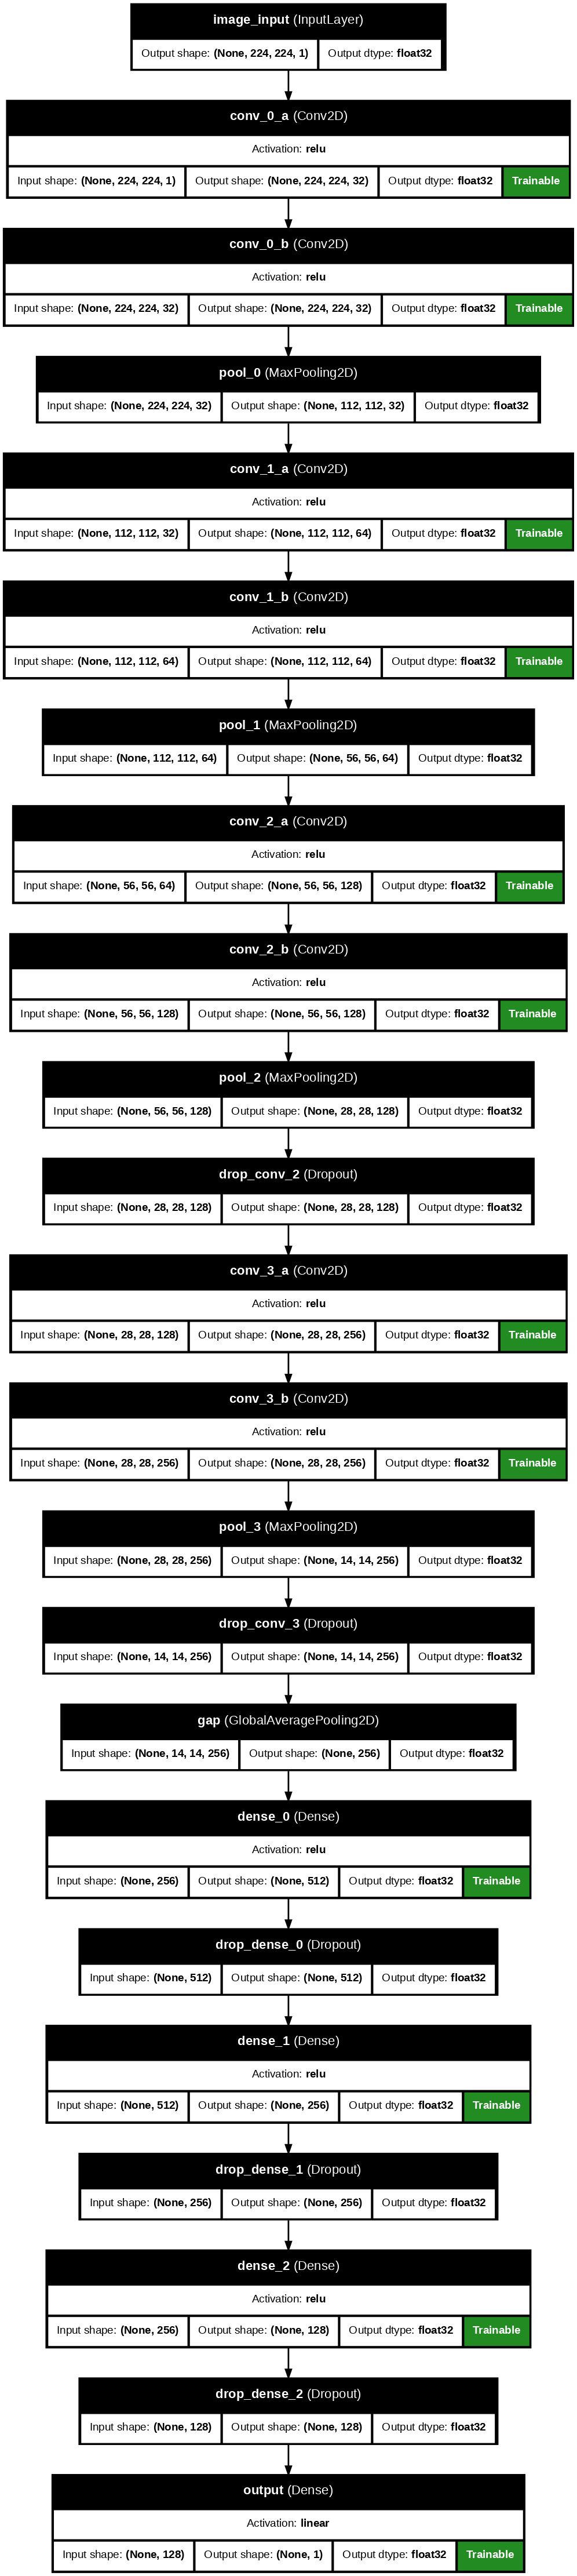

In [14]:
keras.utils.plot_model(
        model=waternet_nofusion,
        to_file="/content/waternet_nofusion.png",
        show_shapes=True,
        show_dtype=True,
        show_layer_names=True,
        rankdir="TB",
        expand_nested=True,
        dpi=100,
        show_layer_activations=True,
        show_trainable=True
    )

## 9.2 Waternet v2 lite (with fusion)

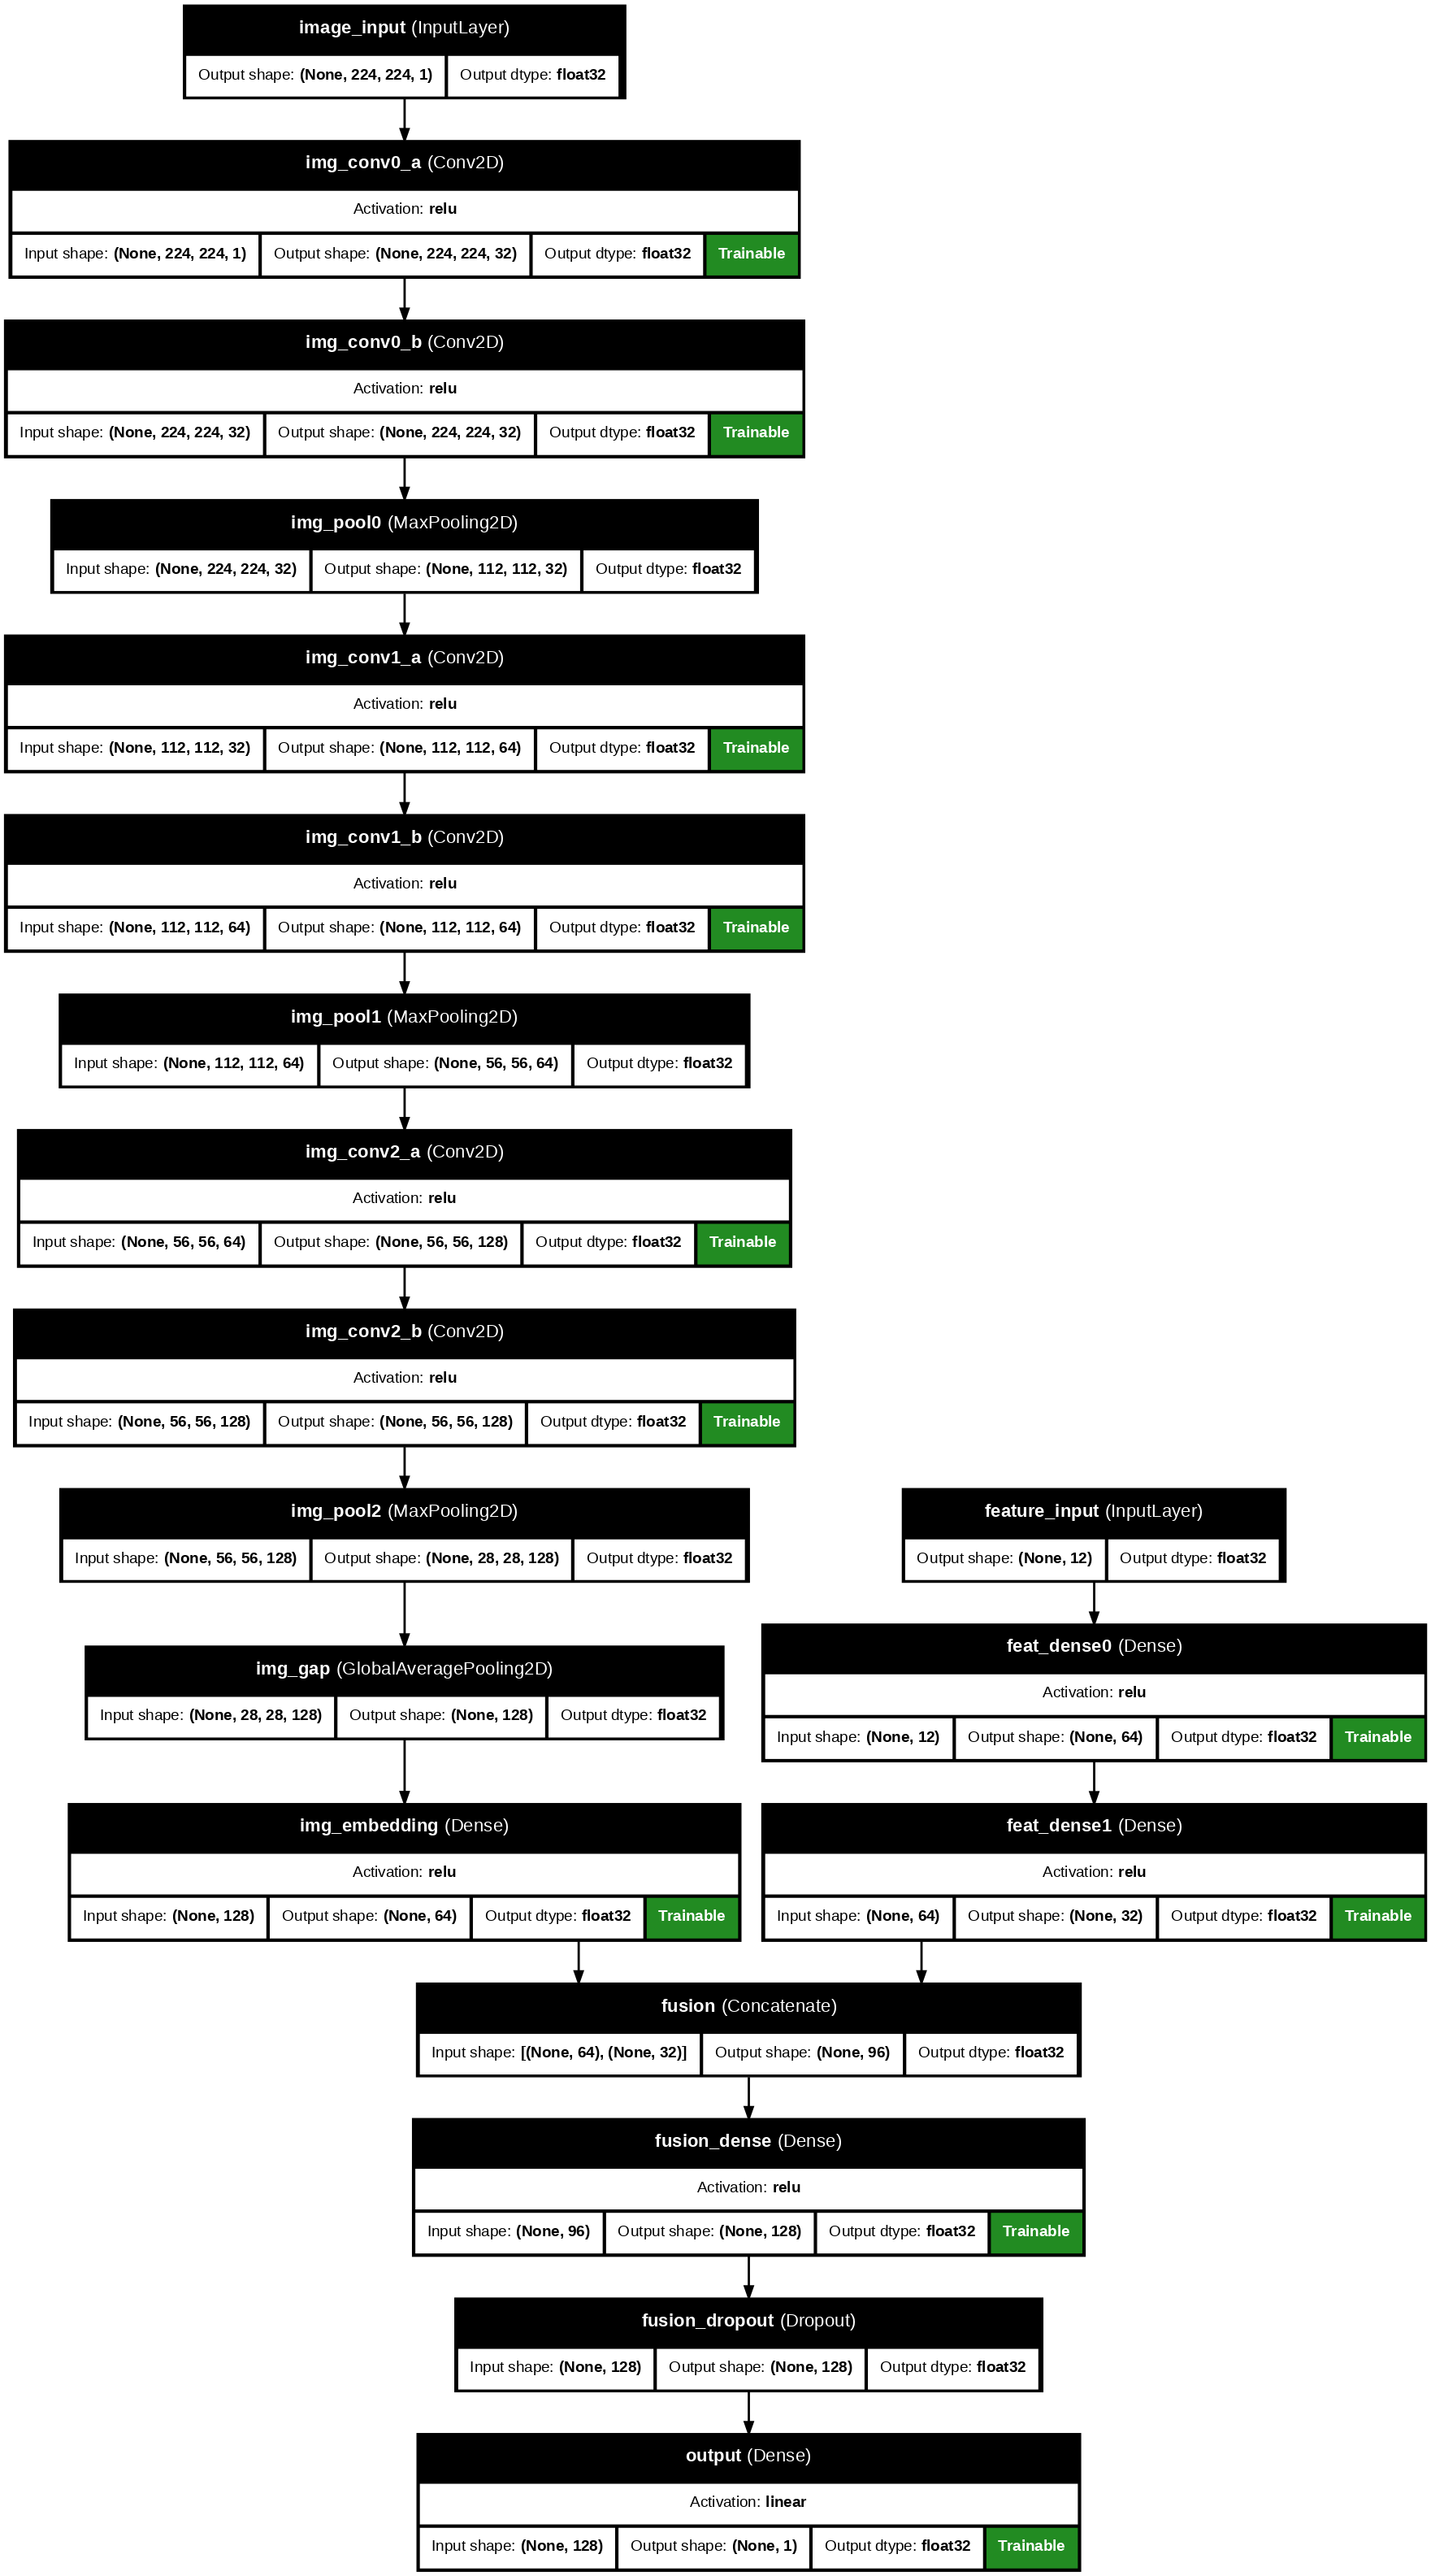

In [13]:
keras.utils.plot_model(
        model=waternet_fusion_lt,
        to_file="/content/waternet_fusion_lt.png",
        show_shapes=True,
        show_dtype=True,
        show_layer_names=True,
        rankdir="TB",
        expand_nested=True,
        dpi=100,
        show_layer_activations=True,
        show_trainable=True
    )

## 9.3 ResNet50 (no-fusion)

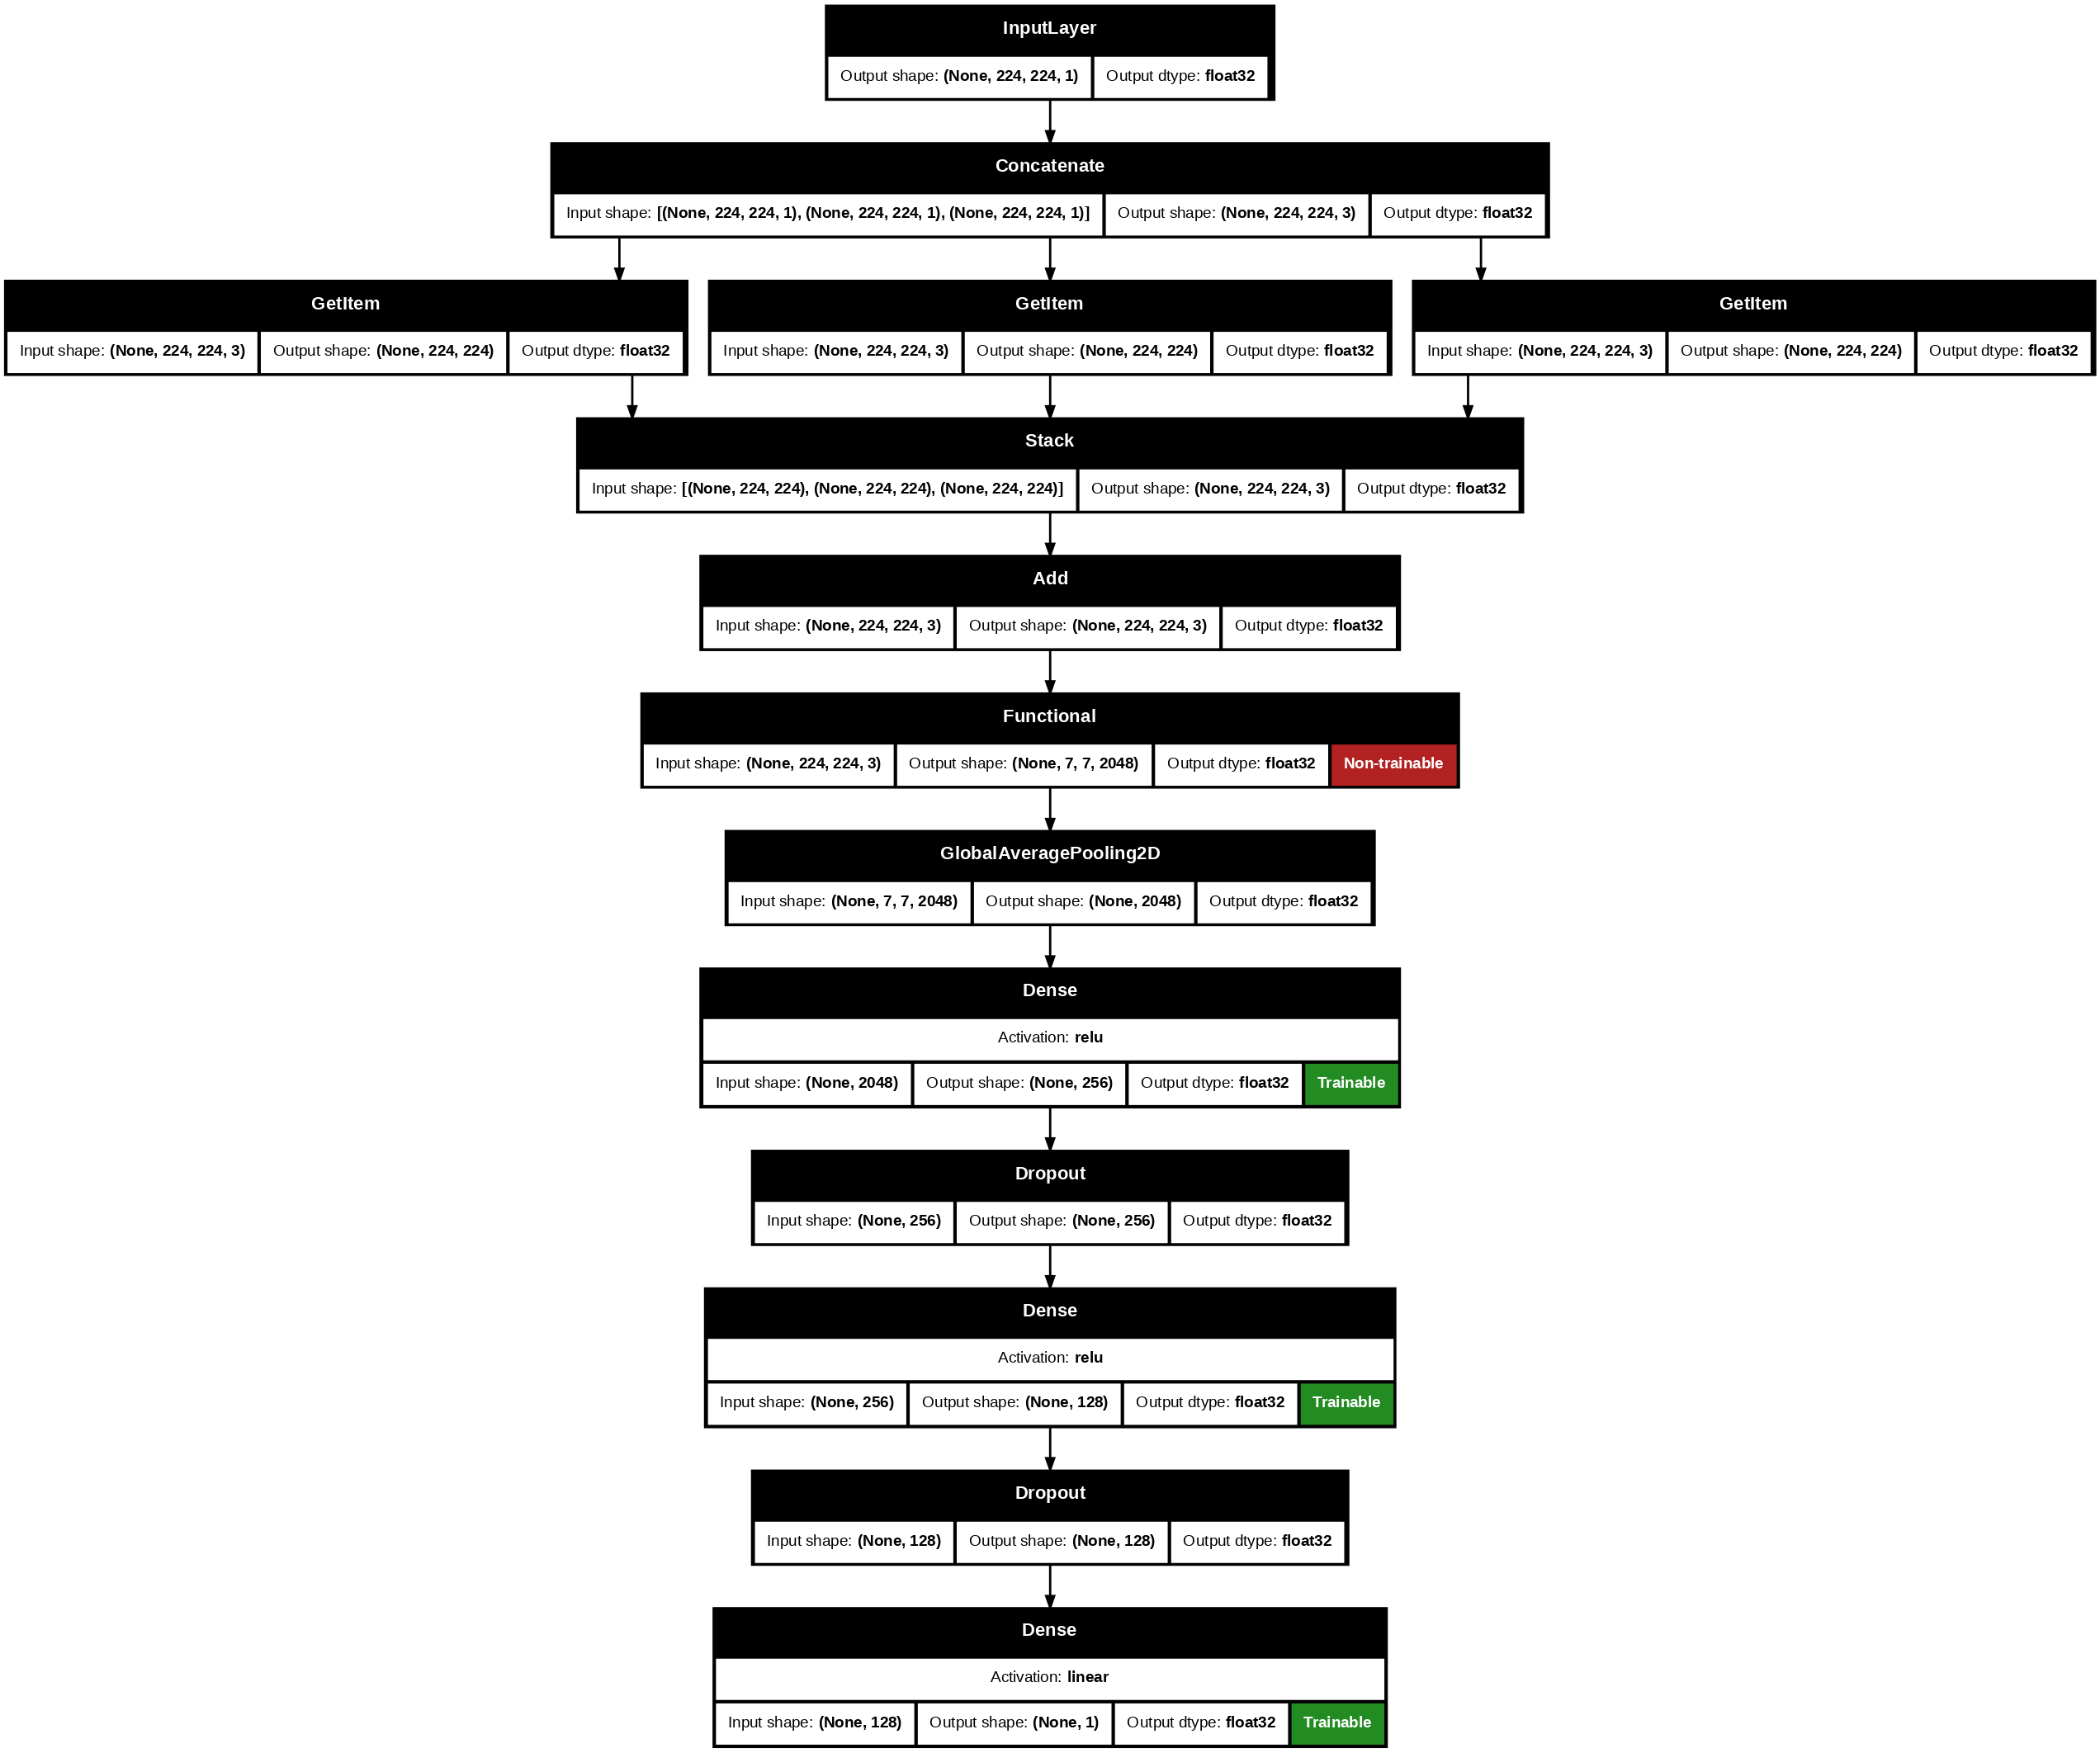

In [23]:
keras.utils.plot_model(
        model=resnet50,
        to_file="/content/resnet50_plot.png",
        show_shapes=True,
        show_dtype=True,
        show_layer_names=False,
        rankdir="TB",
        expand_nested=False,
        dpi=100,
        show_layer_activations=True,
        show_trainable=True
    )

## 9.4 ResNet50 (fusion)

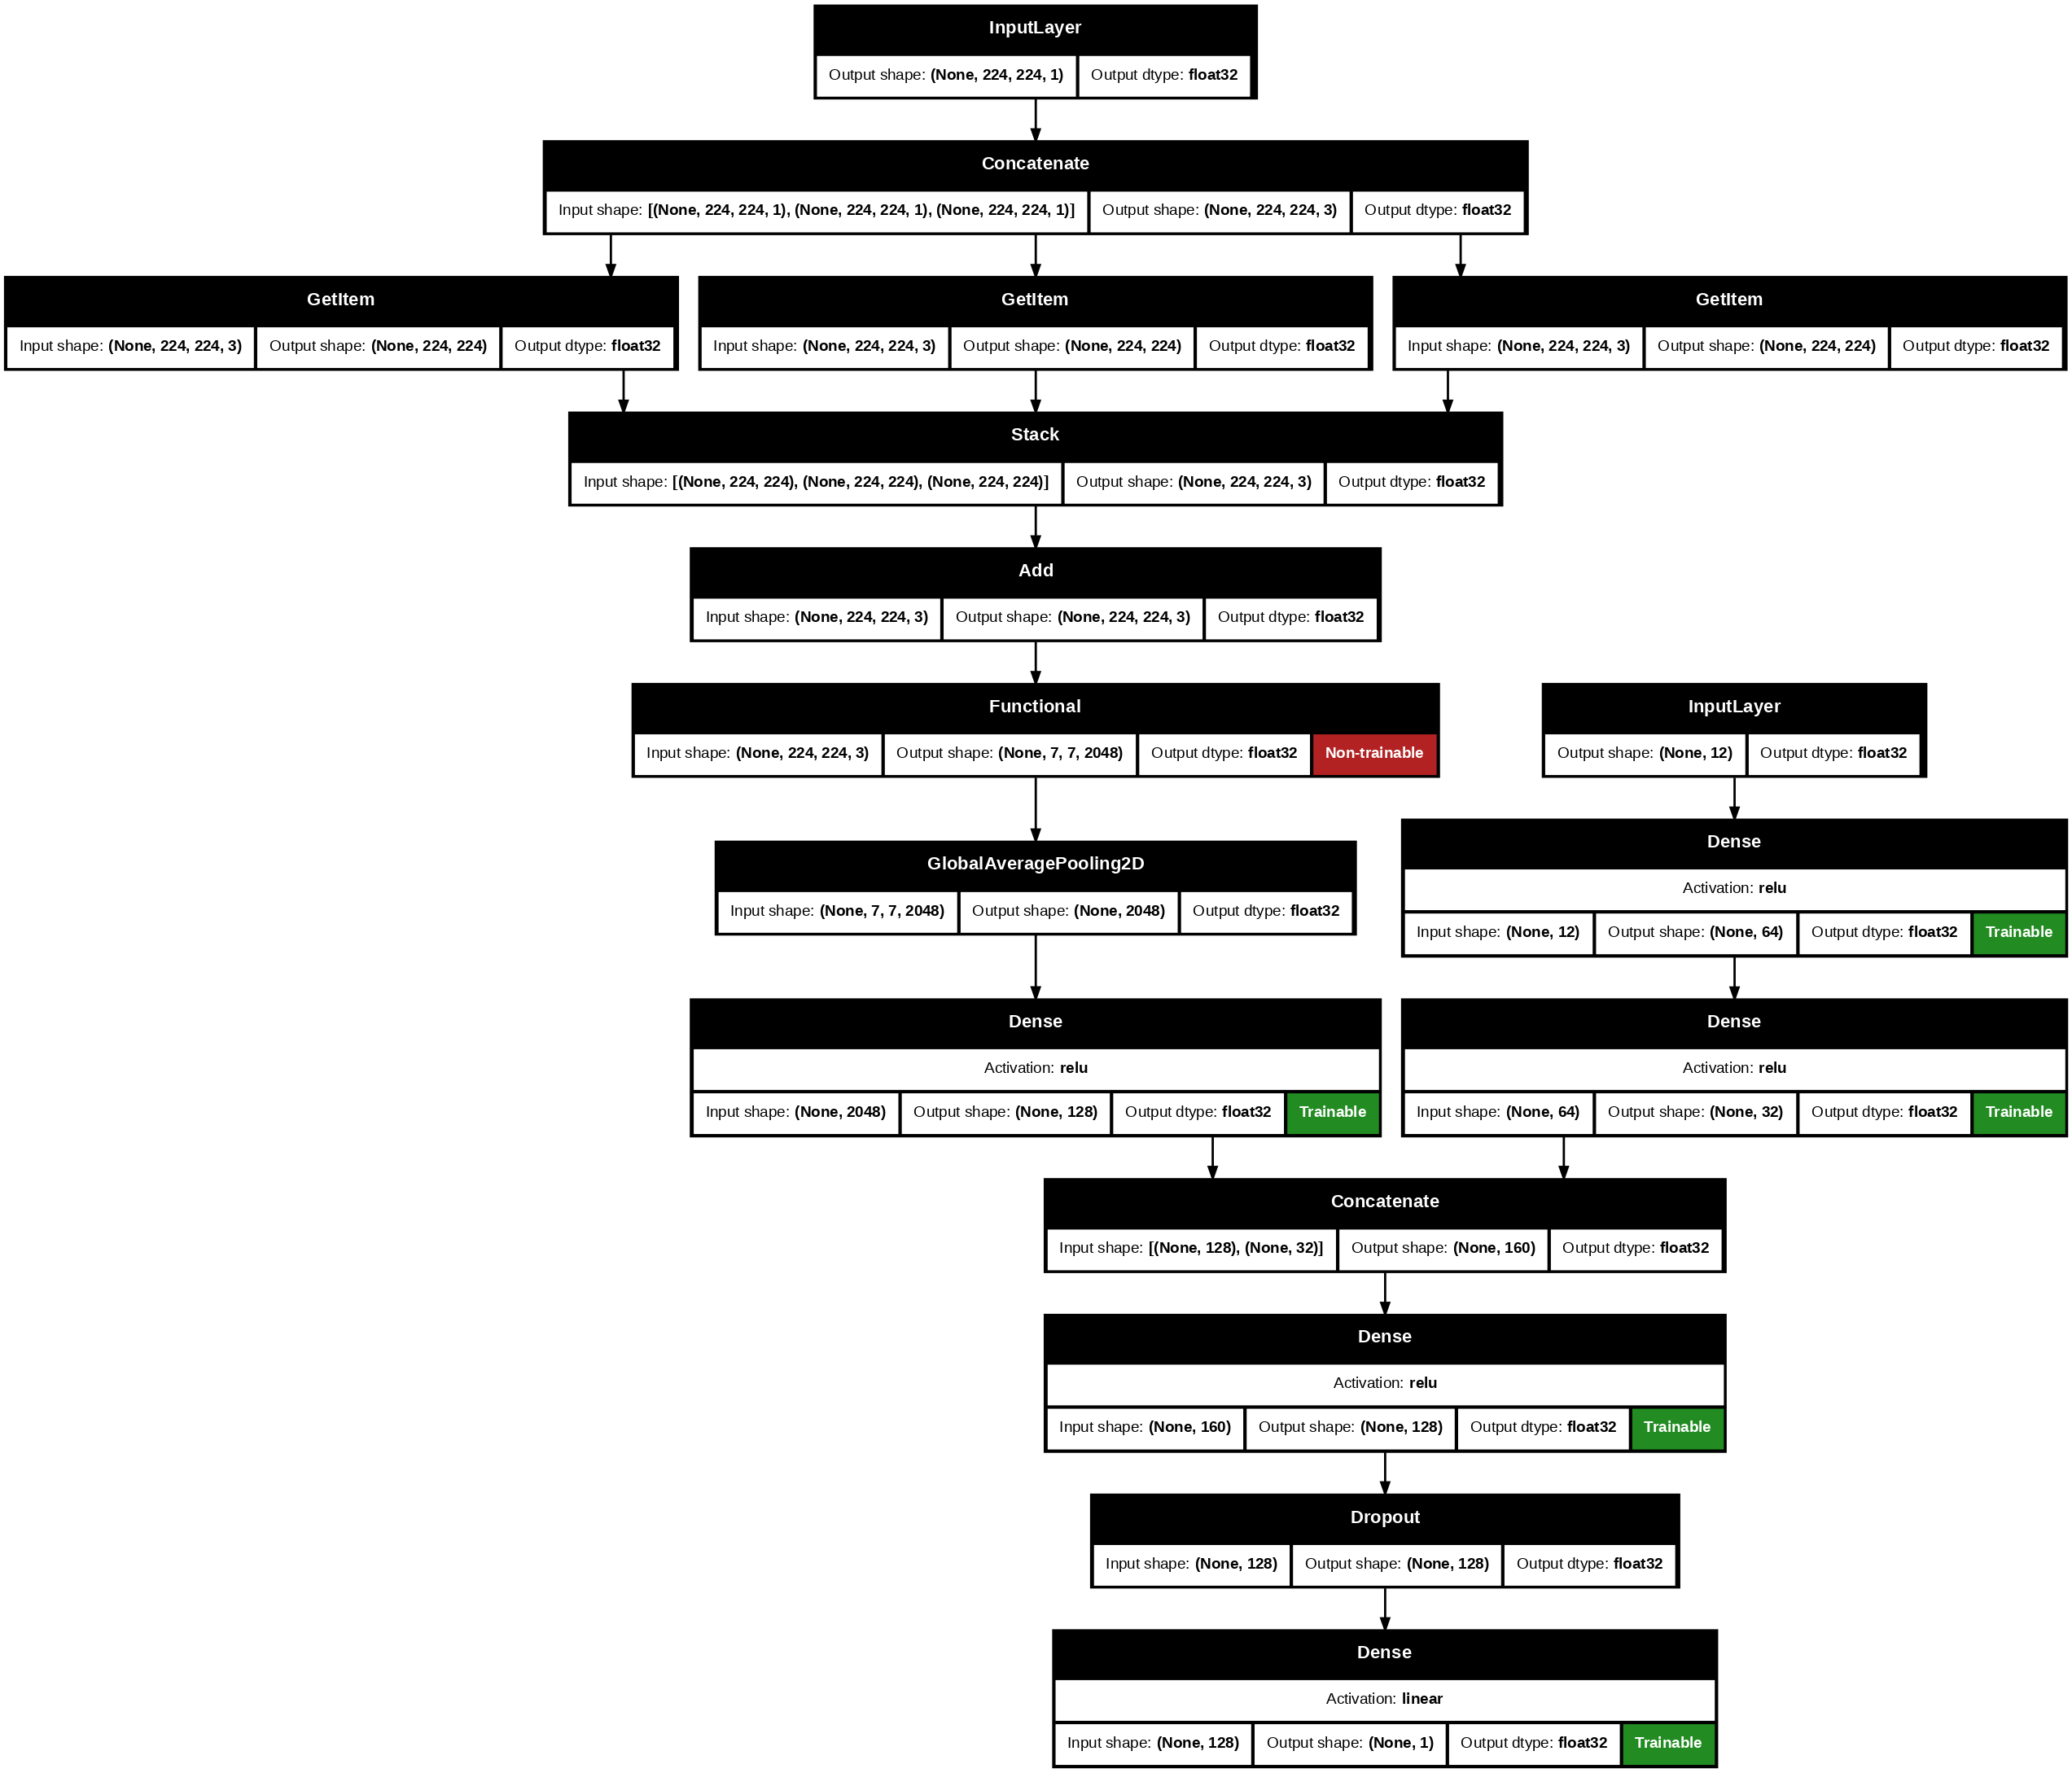

In [25]:
keras.utils.plot_model(
        model=resnet50_fusion,
        to_file="/content/resnet50_fusion_plot.png",
        show_shapes=True,
        show_dtype=True,
        show_layer_names=False,
        rankdir="TB",
        expand_nested=False,
        dpi=100,
        show_layer_activations=True,
        show_trainable=True
    )